# Linear SVM and Maximum Margin Classifier

In this notebook, we will learn:

* What is a Support Vector Machine (SVM)
* Linear classification using SVM
* Hyperplane equation
* Weight vector and bias
* Support vectors
* Maximum margin principle
* Visualization of decision boundary and margins

## Required Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.svm import SVC

## Generating a Linearly Separable Dataset

We create a simple two-class dataset using `make_blobs()`.

The generated dataset is linearly separable, making it suitable for a Linear SVM.

In [2]:
X, y = make_blobs(
    n_samples=100, # total observations
    centers=2,     # two classes
    random_state=42, # reproducible results
    cluster_std=1.1 # spread of each cluster
)

## Training a Linear SVM
A larger value of `C` attempts to classify all training samples correctly, while a smaller value allows a softer margin.

In [3]:
svm = SVC(
    kernel="linear", # creates a linear decision boundary.
    C=10             # penalizes misclassification more strongly.
)

svm.fit(X, y)

,C,10
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## Extracting Model Parameters
The linear decision boundary is:

[
w1 x1 + w2 x2 + b = 0
]

where:

* `w` = weight vector
* `b` = bias

In [4]:
w = svm.coef_[0]
b = svm.intercept_[0]

## Decision Boundary Function
Rearranging the hyperplane equation

This function computes points lying on the decision boundary.

In [5]:
def decision_line(x):
    return -(w[0]*x + b) / w[1]

## Creating X Coordinates
Creates 100 evenly spaced x-values for plotting.

In [6]:
x_vals = np.linspace(
    X[:,0].min(),
    X[:,0].max(),
    100
)

## Computing Margin Width
The margin depends on the magnitude of the weight vector.

A larger margin generally improves generalization.

In [7]:
margin = 1 / np.linalg.norm(w)

## Computing Hyperplane and Margin Boundaries
SVM margin boundaries satisfy:

w^Tx+b=1 and w^Tx+b=-1

These two lines touch the support vectors.

In [8]:
y_vals = decision_line(x_vals)

y_margin_pos = -(w[0]*x_vals + b - 1) / w[1]
y_margin_neg = -(w[0]*x_vals + b + 1) / w[1]

## Visualizing the Maximum Margin Classifier

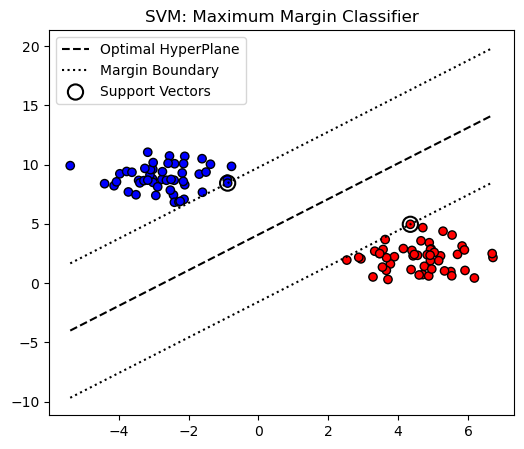

In [9]:
plt.figure(figsize=(6,5))

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="bwr",
    edgecolor="k"
)

plt.plot(
    x_vals,
    y_vals,
    "k--",
    label="Optimal HyperPlane"
)

plt.plot(
    x_vals,
    y_margin_pos,
    "k:",
    label="Margin Boundary"
)

plt.plot(
    x_vals,
    y_margin_neg,
    "k:"
)

plt.scatter(
    svm.support_vectors_[:,0],
    svm.support_vectors_[:,1],
    s=120,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="Support Vectors"
)

plt.title("SVM: Maximum Margin Classifier")
plt.legend()

plt.savefig(
    "linear_svm_margin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Model Information
* Weight vector controls hyperplane orientation.
* Bias controls hyperplane position.
* Margin measures separation between classes.
* Support vectors are the most important observations.

In [10]:
print("Weight vector w:", w)
print("Bias b:", b)
print("Margin (1/||w||):", margin)
print("Number of support vectors:", len(svm.support_vectors_))

Weight vector w: [ 0.26506647 -0.17623745]
Bias b: 0.7223721957923663
Margin (1/||w||): 3.141612960382368
Number of support vectors: 2
